# 🔍 Twitter Sentiment Analysis — Training Data Exploration & Refinement

This notebook explores and refines the **Twitter training dataset** using `pandas` and `matplotlib`.  
We'll examine the data structure, clean it up, visualize distributions, and prepare it for model training.

## 1. Setup & Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Matplotlib styling
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 13

print('Libraries loaded successfully! ✅')

Libraries loaded successfully! ✅


## 2. Load the Training Dataset

In [2]:
# Load dataset — no header row in CSV
df = pd.read_csv('twitter_training.csv', header=None,
                  names=['TweetID', 'Topic', 'Sentiment', 'Text'])

print(f'Dataset shape: {df.shape}')
print(f'Total rows: {df.shape[0]:,}')
print(f'Total columns: {df.shape[1]}')
df.head(10)

Dataset shape: (74682, 4)
Total rows: 74,682
Total columns: 4


,TweetID,Topic,Sentiment,Text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
5,2401,Borderlands,Positive,im getting into borderlands and i can murder y...
6,2402,Borderlands,Positive,So I spent a few hours making something for fu...
7,2402,Borderlands,Positive,So I spent a couple of hours doing something f...
8,2402,Borderlands,Positive,So I spent a few hours doing something for fun...
9,2402,Borderlands,Positive,So I spent a few hours making something for fu...


## 3. Basic Data Inspection

In [3]:
# Data types and memory usage
print('=== Data Types ===')
print(df.dtypes)
print(f'\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
print()
df.info()

=== Data Types ===
TweetID       int64
Topic        object
Sentiment    object
Text         object
dtype: object

Memory usage: 23.69 MB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   TweetID    74682 non-null  int64 
 1   Topic      74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Text       73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [4]:
# Statistical summary
df.describe(include='all')

,TweetID,Topic,Sentiment,Text
count,74682.000000,74682,74682,73996
unique,NaN,32,4,69491
top,NaN,Microsoft,Negative,"At the same time, despite the fact that there ..."
freq,NaN,2400,22542,172
mean,6432.586165,NaN,NaN,NaN
std,3740.427870,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN
25%,3195.000000,NaN,NaN,NaN
50%,6422.000000,NaN,NaN,NaN
75%,9601.000000,NaN,NaN,NaN


In [5]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('=== Missing Values ===')
print(missing_df)
print(f'\nTotal missing cells: {df.isnull().sum().sum()}')

=== Missing Values ===
           Missing Count  Missing %
TweetID                0   0.000000
Topic                  0   0.000000
Sentiment              0   0.000000
Text                 686   0.918561

Total missing cells: 686


In [6]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f'Duplicate rows: {duplicates} ({duplicates/len(df)*100:.2f}%)')

# Check for duplicate text entries
text_duplicates = df['Text'].duplicated().sum()
print(f'Duplicate text entries: {text_duplicates} ({text_duplicates/len(df)*100:.2f}%)')

Duplicate rows: 2700 (3.62%)
Duplicate text entries: 5190 (6.95%)


## 4. Sentiment Distribution Analysis

=== Sentiment Distribution ===
  Negative    : 22,542 (30.2%)
  Positive    : 20,832 (27.9%)
  Neutral     : 18,318 (24.5%)
  Irrelevant  : 12,990 (17.4%)


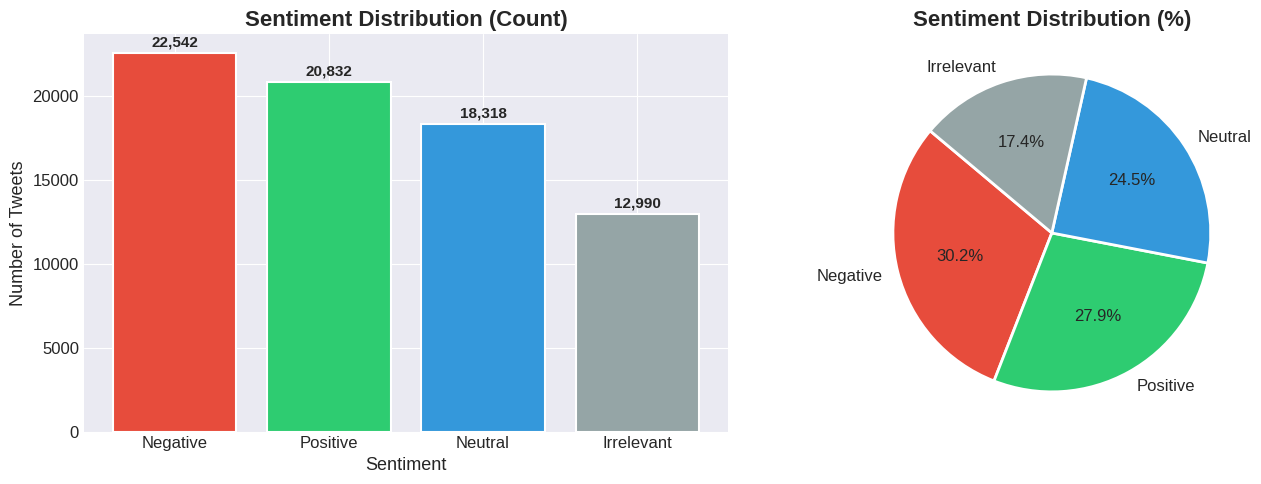

In [7]:
# Sentiment value counts
sentiment_counts = df['Sentiment'].value_counts()
print('=== Sentiment Distribution ===')
for sent, count in sentiment_counts.items():
    print(f'  {sent:12s}: {count:6,} ({count/len(df)*100:.1f}%)')

# Bar chart with custom colors
colors = {'Positive': '#2ecc71', 'Negative': '#e74c3c',
          'Neutral': '#3498db', 'Irrelevant': '#95a5a6'}
bar_colors = [colors.get(s, '#9b59b6') for s in sentiment_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=bar_colors,
                   edgecolor='white', linewidth=1.5)
axes[0].set_title('Sentiment Distribution (Count)', fontweight='bold')
axes[0].set_ylabel('Number of Tweets')
axes[0].set_xlabel('Sentiment')
for bar, count in zip(bars, sentiment_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{count:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Pie chart
axes[1].pie(sentiment_counts.values, labels=sentiment_counts.index,
            autopct='%1.1f%%', colors=bar_colors, startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Sentiment Distribution (%)', fontweight='bold')

plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Topic Distribution Analysis

Unique topics: 32

=== Top 15 Topics ===
Topic
Microsoft                    2400
MaddenNFL                    2400
TomClancysRainbowSix         2400
LeagueOfLegends              2394
CallOfDuty                   2394
Verizon                      2382
CallOfDutyBlackopsColdWar    2376
ApexLegends                  2376
Facebook                     2370
WorldOfCraft                 2364
Dota2                        2364
NBA2K                        2352
TomClancysGhostRecon         2346
Battlefield                  2346
FIFA                         2340
Name: count, dtype: int64


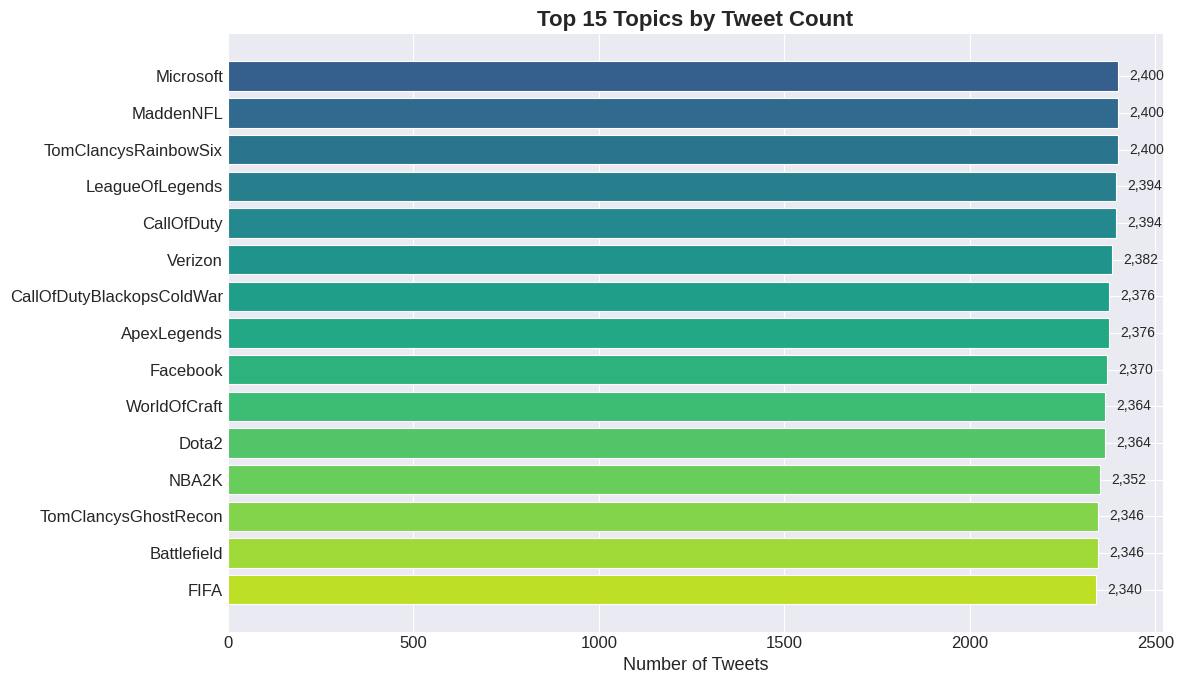

In [8]:
# Topics overview
topic_counts = df['Topic'].value_counts()
print(f'Unique topics: {df["Topic"].nunique()}')
print(f'\n=== Top 15 Topics ===')
print(topic_counts.head(15))

# Horizontal bar chart for top 15 topics
fig, ax = plt.subplots(figsize=(12, 7))
top_topics = topic_counts.head(15)
y_pos = range(len(top_topics))

gradient_colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_topics)))
bars = ax.barh(y_pos, top_topics.values, color=gradient_colors,
               edgecolor='white', linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(top_topics.index)
ax.invert_yaxis()
ax.set_xlabel('Number of Tweets')
ax.set_title('Top 15 Topics by Tweet Count', fontweight='bold')

for bar, val in zip(bars, top_topics.values):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('topic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Sentiment by Topic (Cross Analysis)

=== Sentiment Breakdown by Top 10 Topics ===
Sentiment                  Irrelevant  Negative  Neutral  Positive
Topic                                                             
Microsoft                         174       774      846       606
MaddenNFL                          90      1710      204       396
TomClancysRainbowSix               96      1122      654       528
LeagueOfLegends                   312       642      822       618
CallOfDuty                        672       894      378       450
Verizon                           186      1098      570       528
CallOfDutyBlackopsColdWar         576       576      360       864
ApexLegends                       192       600      942       642
Facebook                          690       720      786       174
WorldOfCraft                      216       342     1068       738


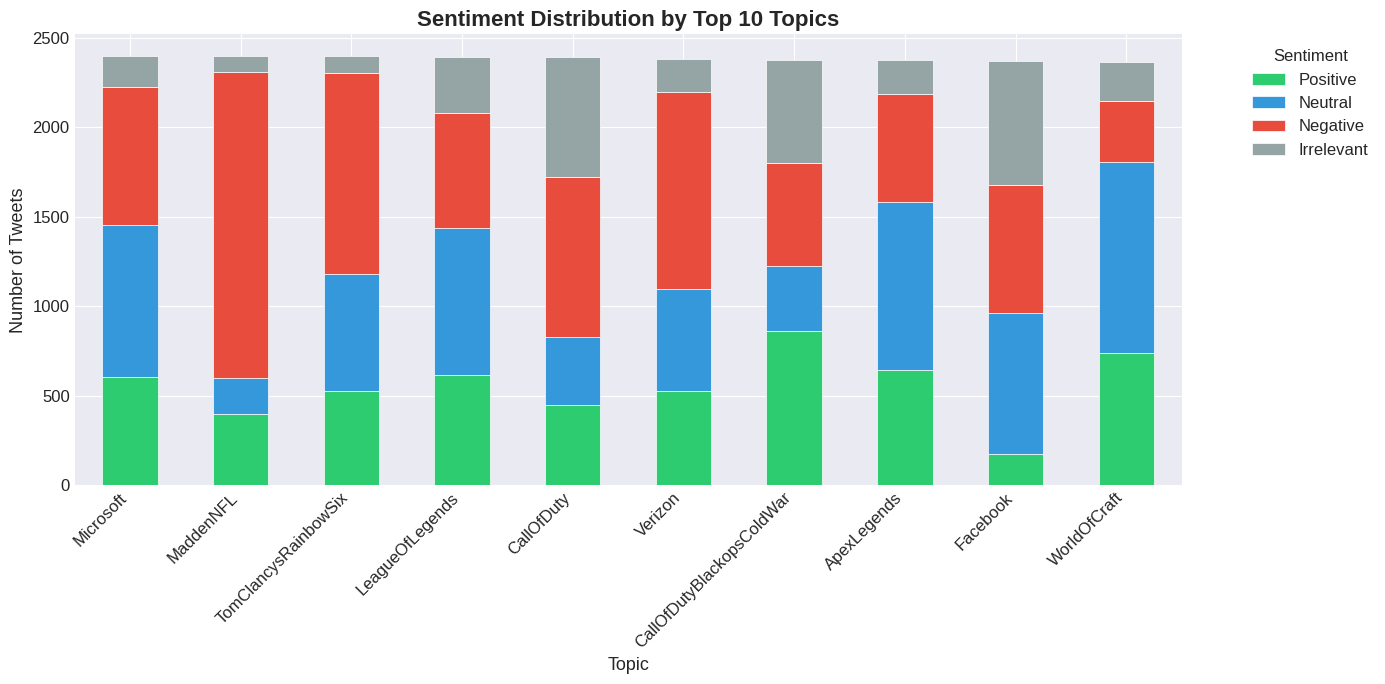

In [9]:
# Cross-tabulation: Sentiment vs Topic (Top 10 topics)
top_10_topics = df['Topic'].value_counts().head(10).index
df_top = df[df['Topic'].isin(top_10_topics)]

cross_tab = pd.crosstab(df_top['Topic'], df_top['Sentiment'])
cross_tab = cross_tab.loc[top_10_topics]  # maintain order

print('=== Sentiment Breakdown by Top 10 Topics ===')
print(cross_tab)

# Stacked bar chart
fig, ax = plt.subplots(figsize=(14, 7))
sent_order = ['Positive', 'Neutral', 'Negative', 'Irrelevant']
color_map = {'Positive': '#2ecc71', 'Negative': '#e74c3c',
             'Neutral': '#3498db', 'Irrelevant': '#95a5a6'}

cross_tab_ordered = cross_tab[[s for s in sent_order if s in cross_tab.columns]]
cross_tab_ordered.plot(kind='bar', stacked=True, ax=ax,
                       color=[color_map[s] for s in cross_tab_ordered.columns],
                       edgecolor='white', linewidth=0.5)
ax.set_title('Sentiment Distribution by Top 10 Topics', fontweight='bold')
ax.set_ylabel('Number of Tweets')
ax.set_xlabel('Topic')
ax.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('sentiment_by_topic.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Text Length Analysis

In [10]:
# Compute text lengths
df['TextLength'] = df['Text'].astype(str).apply(len)
df['WordCount'] = df['Text'].astype(str).apply(lambda x: len(x.split()))

print('=== Text Length Stats (characters) ===')
print(df['TextLength'].describe())
print(f'\n=== Word Count Stats ===')
print(df['WordCount'].describe())

=== Text Length Stats (characters) ===
count    74682.000000
mean       107.811963
std         79.798839
min          1.000000
25%         45.000000
50%         90.000000
75%        152.000000
max        957.000000
Name: TextLength, dtype: float64

=== Word Count Stats ===
count    74682.000000
mean        19.059198
std         14.480861
min          0.000000
25%          8.000000
50%         15.000000
75%         27.000000
max        198.000000
Name: WordCount, dtype: float64


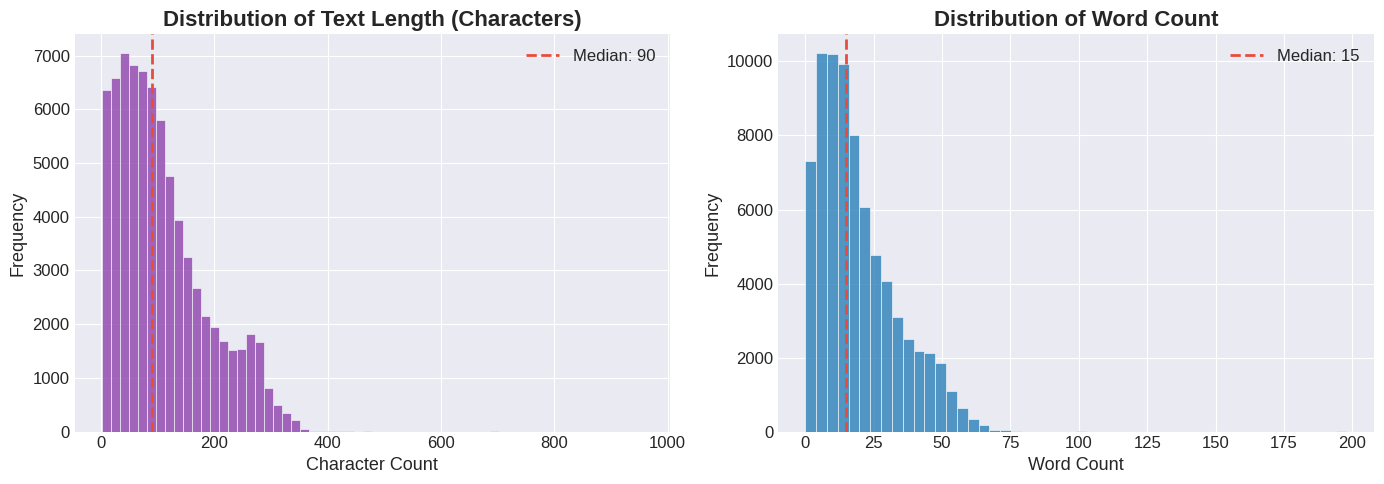

In [11]:
# Distribution of text lengths
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Character length histogram
axes[0].hist(df['TextLength'], bins=60, color='#8e44ad', alpha=0.8,
             edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribution of Text Length (Characters)', fontweight='bold')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['TextLength'].median(), color='#e74c3c',
                linestyle='--', linewidth=2, label=f'Median: {df["TextLength"].median():.0f}')
axes[0].legend()

# Word count histogram
axes[1].hist(df['WordCount'], bins=50, color='#2980b9', alpha=0.8,
             edgecolor='white', linewidth=0.5)
axes[1].set_title('Distribution of Word Count', fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df['WordCount'].median(), color='#e74c3c',
                linestyle='--', linewidth=2, label=f'Median: {df["WordCount"].median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_2037/4189824564.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=sentiment_order, patch_artist=True,


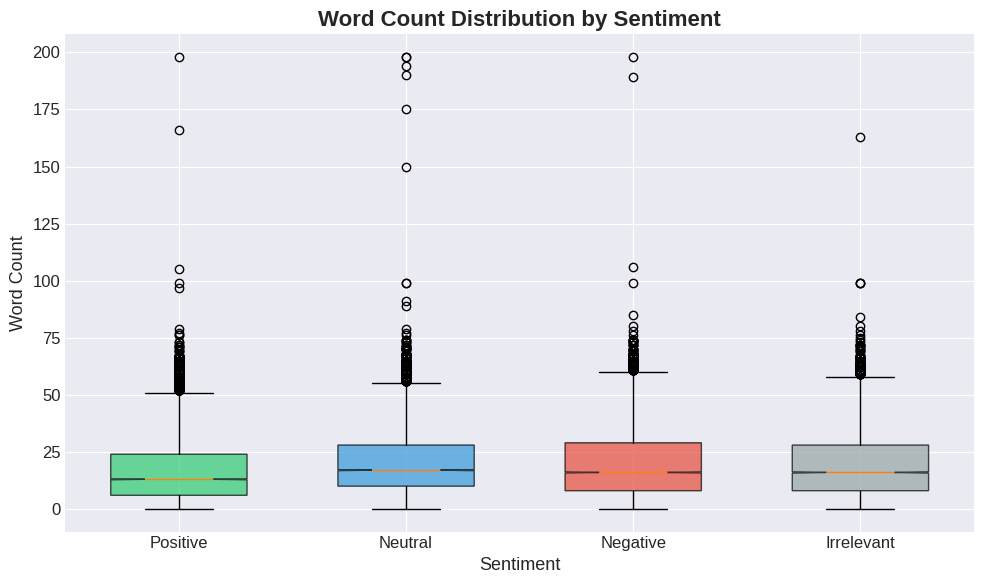

In [12]:
# Text length by sentiment — box plot
fig, ax = plt.subplots(figsize=(10, 6))

sentiment_order = ['Positive', 'Neutral', 'Negative', 'Irrelevant']
box_data = [df[df['Sentiment'] == s]['WordCount'].values for s in sentiment_order]

bp = ax.boxplot(box_data, labels=sentiment_order, patch_artist=True,
                notch=True, widths=0.6)

box_colors = ['#2ecc71', '#3498db', '#e74c3c', '#95a5a6']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Word Count Distribution by Sentiment', fontweight='bold')
ax.set_ylabel('Word Count')
ax.set_xlabel('Sentiment')
plt.tight_layout()
plt.savefig('wordcount_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Data Cleaning & Refinement

In [13]:
print(f'Original dataset size: {len(df):,} rows')

# --- Step 1: Drop rows with missing text ---
df_clean = df.dropna(subset=['Text']).copy()
print(f'After dropping NaN text: {len(df_clean):,} rows (removed {len(df) - len(df_clean):,})')

# --- Step 2: Remove empty or very short texts (< 3 characters) ---
df_clean = df_clean[df_clean['Text'].astype(str).str.strip().str.len() >= 3]
print(f'After removing short text (<3 chars): {len(df_clean):,} rows')

# --- Step 3: Strip whitespace from text and sentiment columns ---
df_clean['Text'] = df_clean['Text'].astype(str).str.strip()
df_clean['Sentiment'] = df_clean['Sentiment'].astype(str).str.strip()
df_clean['Topic'] = df_clean['Topic'].astype(str).str.strip()

# --- Step 4: Remove duplicate text entries (keep first occurrence) ---
before_dedup = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['Text'], keep='first')
print(f'After deduplication: {len(df_clean):,} rows (removed {before_dedup - len(df_clean):,} duplicates)')

# --- Step 5: Validate sentiment labels ---
valid_sentiments = ['Positive', 'Negative', 'Neutral', 'Irrelevant']
invalid_mask = ~df_clean['Sentiment'].isin(valid_sentiments)
print(f'Invalid sentiment labels found: {invalid_mask.sum()}')
if invalid_mask.sum() > 0:
    print(f'  Invalid values: {df_clean[invalid_mask]["Sentiment"].unique()}')
    df_clean = df_clean[~invalid_mask]

print(f'\n✅ Final cleaned dataset size: {len(df_clean):,} rows')
print(f'   Rows removed: {len(df) - len(df_clean):,} ({(len(df) - len(df_clean))/len(df)*100:.1f}%)')

Original dataset size: 74,682 rows
After dropping NaN text: 73,996 rows (removed 686)
After removing short text (<3 chars): 73,140 rows
After deduplication: 69,091 rows (removed 4,049 duplicates)
Invalid sentiment labels found: 0

✅ Final cleaned dataset size: 69,091 rows
   Rows removed: 5,591 (7.5%)


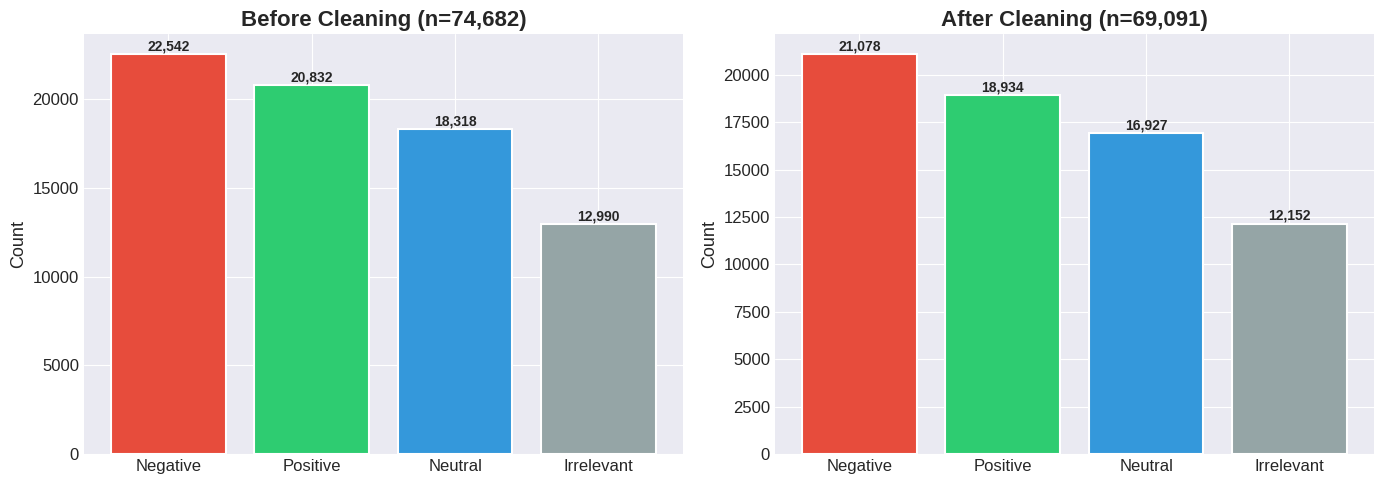

In [14]:
# Compare before vs after cleaning
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original distribution
orig_counts = df['Sentiment'].value_counts()
orig_colors = [colors.get(s, '#9b59b6') for s in orig_counts.index]
axes[0].bar(orig_counts.index, orig_counts.values, color=orig_colors,
            edgecolor='white', linewidth=1.5)
axes[0].set_title(f'Before Cleaning (n={len(df):,})', fontweight='bold')
axes[0].set_ylabel('Count')
for i, (idx, val) in enumerate(orig_counts.items()):
    axes[0].text(i, val + 200, f'{val:,}', ha='center', fontweight='bold', fontsize=10)

# Cleaned distribution
clean_counts = df_clean['Sentiment'].value_counts()
clean_colors = [colors.get(s, '#9b59b6') for s in clean_counts.index]
axes[1].bar(clean_counts.index, clean_counts.values, color=clean_colors,
            edgecolor='white', linewidth=1.5)
axes[1].set_title(f'After Cleaning (n={len(df_clean):,})', fontweight='bold')
axes[1].set_ylabel('Count')
for i, (idx, val) in enumerate(clean_counts.items()):
    axes[1].text(i, val + 200, f'{val:,}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('before_after_cleaning.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Advanced Text Cleaning

In [15]:
import re

def clean_text(text):
    """Apply text cleaning transformations."""
    text = str(text)
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\S+\.com\S*', '', text)
    text = re.sub(r'\S+\.co/\S*', '', text)
    text = re.sub(r'pic\.\S+', '', text)
    # Remove @mentions (but keep the text context)
    text = re.sub(r'@\w+', '', text)
    # Remove the <unk> token
    text = re.sub(r'<unk>', '', text)
    # Remove RhandlerR placeholder
    text = re.sub(r'RhandlerR', '', text)
    # Remove RhttpR placeholder
    text = re.sub(r'RhttpR', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_clean['CleanedText'] = df_clean['Text'].apply(clean_text)

# Show some examples
print('=== Sample Cleaned Texts ===')
sample = df_clean[['Text', 'CleanedText', 'Sentiment']].sample(5, random_state=42)
for _, row in sample.iterrows():
    print(f'\n[{row["Sentiment"]}]')
    print(f'  Original:  {row["Text"][:100]}...')
    print(f'  Cleaned:   {row["CleanedText"][:100]}...')

=== Sample Cleaned Texts ===

[Neutral]
  Original:  Too connected: FTC eyes Facebook antitrust violation ift.tt/3mNWk3T...
  Cleaned:   Too connected: FTC eyes Facebook antitrust violation ift.tt/3mNWk3T...

[Irrelevant]
  Original:  So the smaller cheaper version of the Xbox Series X is more powerful than the full version of the PS...
  Cleaned:   So the smaller cheaper version of the Xbox Series X is more powerful than the full version of the PS...

[Neutral]
  Original:  In World of Warcraft you can ride a Bee and I can't help but wonder why this hasn't been a thing I'v...
  Cleaned:   In World of Warcraft you can ride a Bee and I can't help but wonder why this hasn't been a thing I'v...

[Negative]
  Original:  you care I’m not buying this crap until the PS5 Pro sells out....
  Cleaned:   you care I’m not buying this crap until the PS5 Pro sells out....

[Neutral]
  Original:  Good morning all TGIF and blessed Valentines Day to you all. What if? Don't live your heart over wha...
 

In [16]:
# Remove rows where cleaned text is too short after cleaning
before = len(df_clean)
df_clean = df_clean[df_clean['CleanedText'].str.len() >= 3]
print(f'Removed {before - len(df_clean)} rows with very short cleaned text')

# Update word count for cleaned text
df_clean['CleanedWordCount'] = df_clean['CleanedText'].apply(lambda x: len(x.split()))

print(f'\n=== Cleaned Text Word Count Stats ===')
print(df_clean['CleanedWordCount'].describe())

Removed 83 rows with very short cleaned text

=== Cleaned Text Word Count Stats ===
count    69008.000000
mean        19.645172
std         14.096807
min          1.000000
25%          9.000000
50%         16.000000
75%         28.000000
max        198.000000
Name: CleanedWordCount, dtype: float64


## 10. Unique Tweet ID Analysis

Unique Tweet IDs: 12,262

=== Augmentations per Tweet ID ===
count    12262.000000
mean         5.627793
std          0.802149
min          1.000000
25%          6.000000
50%          6.000000
75%          6.000000
max          6.000000
dtype: float64


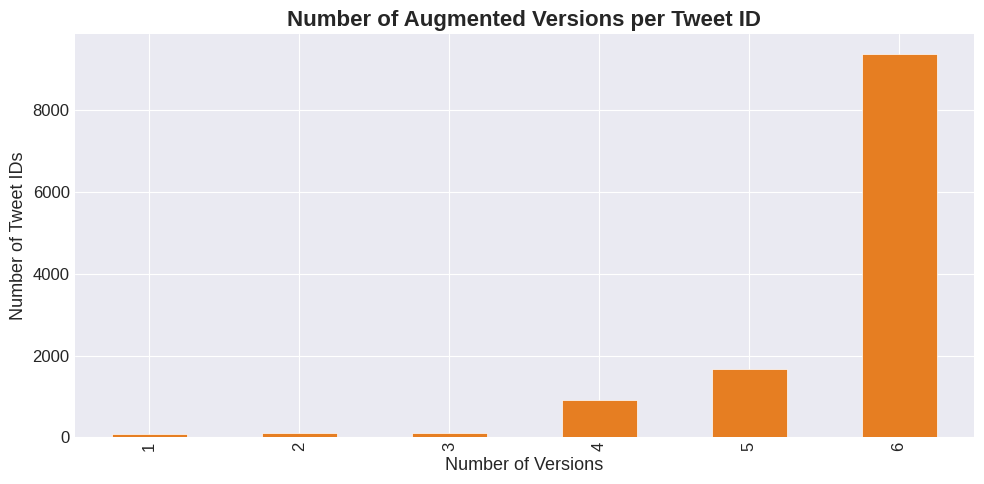

In [17]:
# Each TweetID appears multiple times (augmented versions of same tweet)
tweets_per_id = df_clean.groupby('TweetID').size()

print(f'Unique Tweet IDs: {df_clean["TweetID"].nunique():,}')
print(f'\n=== Augmentations per Tweet ID ===')
print(tweets_per_id.describe())

fig, ax = plt.subplots(figsize=(10, 5))
tweets_per_id.value_counts().sort_index().plot(kind='bar', ax=ax,
    color='#e67e22', edgecolor='white', linewidth=0.5)
ax.set_title('Number of Augmented Versions per Tweet ID', fontweight='bold')
ax.set_xlabel('Number of Versions')
ax.set_ylabel('Number of Tweet IDs')
plt.tight_layout()
plt.savefig('augmentations_per_tweet.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Final Cleaned Dataset Summary

In [18]:
print('=' * 55)
print('        FINAL CLEANED DATASET SUMMARY')
print('=' * 55)
print(f'  Total rows:         {len(df_clean):>10,}')
print(f'  Unique Tweet IDs:   {df_clean["TweetID"].nunique():>10,}')
print(f'  Unique Topics:      {df_clean["Topic"].nunique():>10,}')
print(f'  Sentiment Classes:  {df_clean["Sentiment"].nunique():>10}')
print(f'  Avg Word Count:     {df_clean["CleanedWordCount"].mean():>10.1f}')
print(f'  Median Word Count:  {df_clean["CleanedWordCount"].median():>10.0f}')
print('=' * 55)
print()
print('Sentiment Class Distribution:')
for sent, count in df_clean['Sentiment'].value_counts().items():
    print(f'  {sent:12s}: {count:6,}  ({count/len(df_clean)*100:5.1f}%)')

        FINAL CLEANED DATASET SUMMARY
  Total rows:             69,008
  Unique Tweet IDs:       12,262
  Unique Topics:              32
  Sentiment Classes:           4
  Avg Word Count:           19.6
  Median Word Count:          16

Sentiment Class Distribution:
  Negative    : 21,056  ( 30.5%)
  Positive    : 18,915  ( 27.4%)
  Neutral     : 16,903  ( 24.5%)
  Irrelevant  : 12,134  ( 17.6%)


In [19]:
# Preview final cleaned data
df_clean[['TweetID', 'Topic', 'Sentiment', 'CleanedText', 'CleanedWordCount']].head(10)

,TweetID,Topic,Sentiment,CleanedText,CleanedWordCount
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...,11
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,12
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,10
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,10
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,12
5,2401,Borderlands,Positive,im getting into borderlands and i can murder y...,10
6,2402,Borderlands,Positive,So I spent a few hours making something for fu...,53
7,2402,Borderlands,Positive,So I spent a couple of hours doing something f...,53
8,2402,Borderlands,Positive,So I spent a few hours doing something for fun...,28
9,2402,Borderlands,Positive,So I spent a few hours making something for fu...,53


## 12. Save Cleaned Dataset

In [20]:
# Save the refined dataset
output_cols = ['TweetID', 'Topic', 'Sentiment', 'CleanedText']
df_clean[output_cols].to_csv('twitter_training_cleaned.csv', index=False)

print(f'✅ Cleaned dataset saved to: twitter_training_cleaned.csv')
print(f'   Rows: {len(df_clean):,}')
print(f'   Columns: {len(output_cols)}')

✅ Cleaned dataset saved to: twitter_training_cleaned.csv
   Rows: 69,008
   Columns: 4


---
# 🤖 Part 2: ML Model Training & Validation

Train machine learning models on the cleaned training data and evaluate on the **validation dataset**.

## 13. ML Imports

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score
)
import warnings
warnings.filterwarnings('ignore')

print('Scikit-learn imports loaded ✅')

Scikit-learn imports loaded ✅


## 14. Prepare Training Data (TF-IDF Vectorization)

In [22]:
# Use CleanedText for features, Sentiment as target
X_train = df_clean['CleanedText'].values
y_train = df_clean['Sentiment'].values

# Encode labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)

print(f'Training samples: {len(X_train):,}')
print(f'Label classes: {list(le.classes_)}')
print(f'Label encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Build TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),     # unigrams + bigrams
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
print(f'\nTF-IDF matrix shape: {X_train_tfidf.shape}')
print(f'Vocabulary size: {len(tfidf.vocabulary_):,}')

Training samples: 69,008
Label classes: ['Irrelevant', 'Negative', 'Neutral', 'Positive']
Label encoding: {'Irrelevant': np.int64(0), 'Negative': np.int64(1), 'Neutral': np.int64(2), 'Positive': np.int64(3)}

TF-IDF matrix shape: (69008, 50000)
Vocabulary size: 50,000


## 15. Train Multiple ML Models

In [23]:
import time

# Define models
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=1.0, solver='lbfgs',
        multi_class='multinomial', random_state=42
    ),
    'Linear SVM': LinearSVC(
        max_iter=2000, C=1.0, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=None,
        min_samples_split=5, random_state=42, n_jobs=-1
    )
}

trained_models = {}
train_times = {}

for name, model in models.items():
    print(f'Training {name}...', end=' ')
    start = time.time()
    model.fit(X_train_tfidf, y_train_enc)
    elapsed = time.time() - start
    trained_models[name] = model
    train_times[name] = elapsed

    # Training accuracy
    train_acc = accuracy_score(y_train_enc, model.predict(X_train_tfidf))
    print(f'Done in {elapsed:.1f}s | Train Accuracy: {train_acc:.4f}')

print('\n✅ All models trained!')

Training Logistic Regression... Done in 20.6s | Train Accuracy: 0.9349
Training Linear SVM... Done in 5.5s | Train Accuracy: 0.9827
Training Random Forest... Done in 521.3s | Train Accuracy: 0.9936

✅ All models trained!


## 16. Load & Prepare Validation Dataset

In [24]:
# Load validation data
df_val = pd.read_csv('twitter_validation.csv', header=None,
                      names=['TweetID', 'Topic', 'Sentiment', 'Text'])

print(f'Validation dataset shape: {df_val.shape}')
print(f'Sentiment distribution:\n{df_val["Sentiment"].value_counts()}')

# Apply same cleaning pipeline
df_val = df_val.dropna(subset=['Text'])
df_val['Text'] = df_val['Text'].astype(str).str.strip()
df_val['Sentiment'] = df_val['Sentiment'].astype(str).str.strip()

# Keep only valid sentiment labels
df_val = df_val[df_val['Sentiment'].isin(valid_sentiments)]
df_val['CleanedText'] = df_val['Text'].apply(clean_text)
df_val = df_val[df_val['CleanedText'].str.len() >= 3]

X_val = df_val['CleanedText'].values
y_val = df_val['Sentiment'].values
y_val_enc = le.transform(y_val)

# Transform with the SAME fitted TF-IDF vectorizer
X_val_tfidf = tfidf.transform(X_val)

print(f'\nCleaned validation samples: {len(X_val):,}')
print(f'TF-IDF validation matrix: {X_val_tfidf.shape}')

Validation dataset shape: (1000, 4)
Sentiment distribution:
Sentiment
Neutral       285
Positive      277
Negative      266
Irrelevant    172
Name: count, dtype: int64

Cleaned validation samples: 1,000
TF-IDF validation matrix: (1000, 50000)


## 17. Evaluate Models on Validation Set

In [25]:
results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_val_tfidf)
    acc = accuracy_score(y_val_enc, y_pred)
    f1 = f1_score(y_val_enc, y_pred, average='weighted')
    results[name] = {
        'accuracy': acc, 'f1_weighted': f1, 'predictions': y_pred
    }

    print(f'\n{"=" * 60}')
    print(f'  {name}')
    print(f'{"=" * 60}')
    print(f'  Accuracy:          {acc:.4f} ({acc*100:.2f}%)')
    print(f'  Weighted F1-Score: {f1:.4f}')
    print(f'  Training Time:     {train_times[name]:.1f}s')
    print(f'\n  Classification Report:')
    print(classification_report(y_val_enc, y_pred,
          target_names=le.classes_, digits=4))


  Logistic Regression
  Accuracy:          0.9680 (96.80%)
  Weighted F1-Score: 0.9679
  Training Time:     20.6s

  Classification Report:
              precision    recall  f1-score   support

  Irrelevant     0.9758    0.9360    0.9555       172
    Negative     0.9560    0.9812    0.9685       266
     Neutral     0.9755    0.9789    0.9772       285
    Positive     0.9674    0.9639    0.9656       277

    accuracy                         0.9680      1000
   macro avg     0.9687    0.9650    0.9667      1000
weighted avg     0.9681    0.9680    0.9679      1000


  Linear SVM
  Accuracy:          0.9740 (97.40%)
  Weighted F1-Score: 0.9740
  Training Time:     5.5s

  Classification Report:
              precision    recall  f1-score   support

  Irrelevant     0.9766    0.9709    0.9738       172
    Negative     0.9667    0.9812    0.9739       266
     Neutral     0.9892    0.9614    0.9751       285
    Positive     0.9645    0.9819    0.9732       277

    accuracy         

## 18. Confusion Matrices

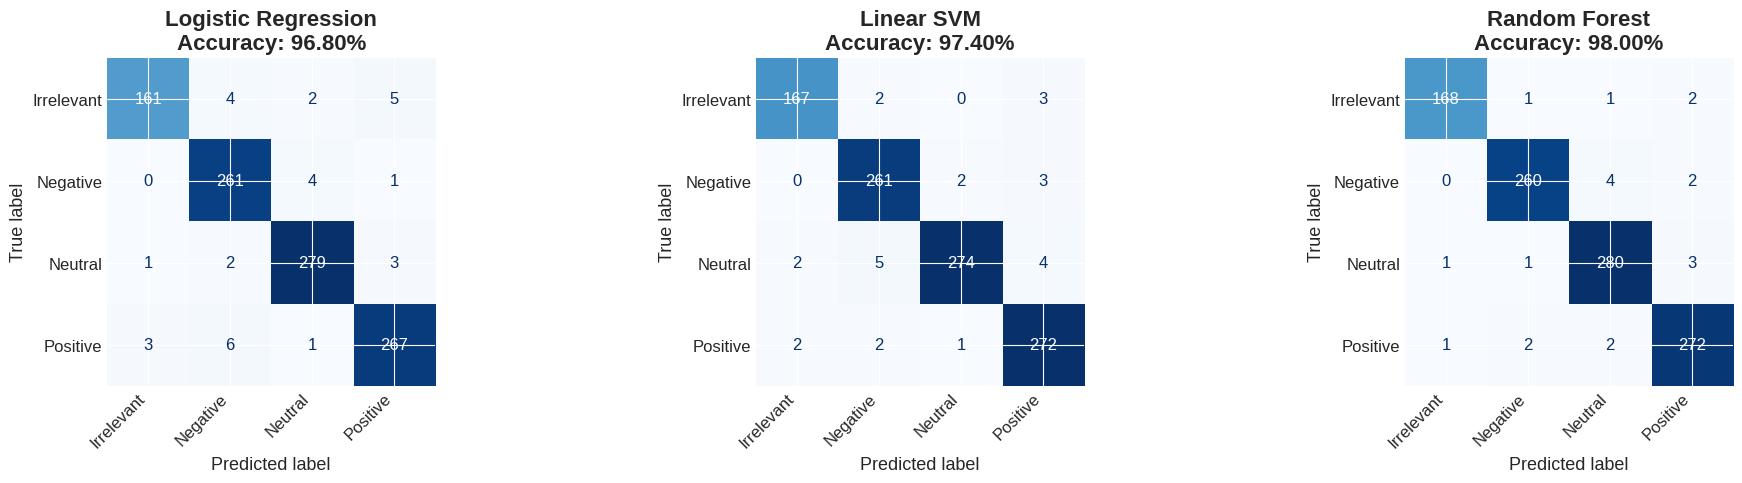

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_val_enc, res['predictions'])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=le.classes_
    )
    disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
    ax.set_title(f'{name}\nAccuracy: {res["accuracy"]*100:.2f}%',
                 fontweight='bold')
    ax.set_xticklabels(le.classes_, rotation=45, ha='right')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 19. Model Accuracy Comparison

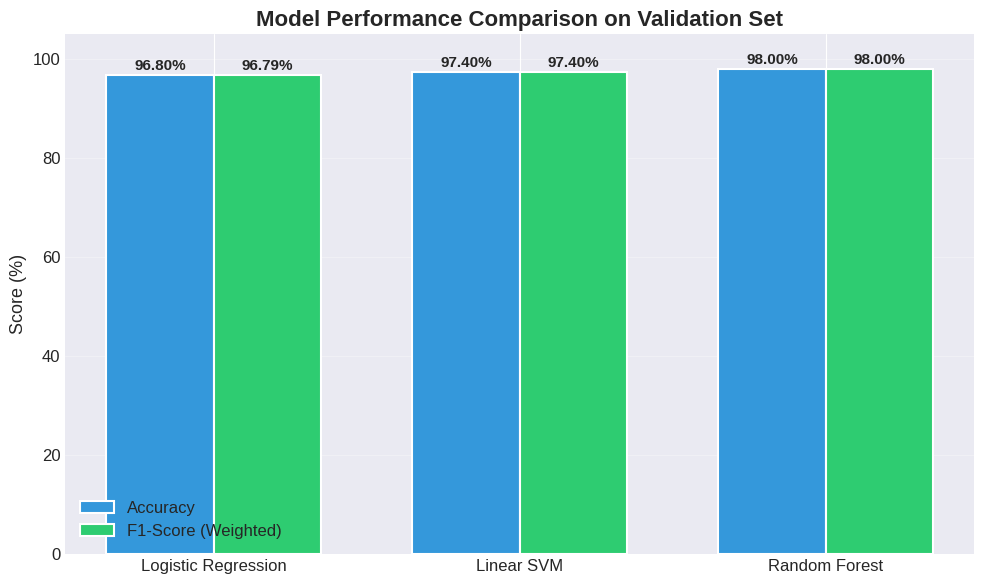

In [27]:
model_names = list(results.keys())
accuracies = [results[m]['accuracy'] * 100 for m in model_names]
f1_scores_list = [results[m]['f1_weighted'] * 100 for m in model_names]

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(model_names))
width = 0.35

bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy',
               color='#3498db', edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x + width/2, f1_scores_list, width,
               label='F1-Score (Weighted)',
               color='#2ecc71', edgecolor='white', linewidth=1.5)

ax.set_ylabel('Score (%)', fontsize=13)
ax.set_title('Model Performance Comparison on Validation Set',
             fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=12)
ax.legend(fontsize=12)
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.2f}%', ha='center',
            fontweight='bold', fontsize=11)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.2f}%', ha='center',
            fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 20. Per-Class F1 Score Breakdown

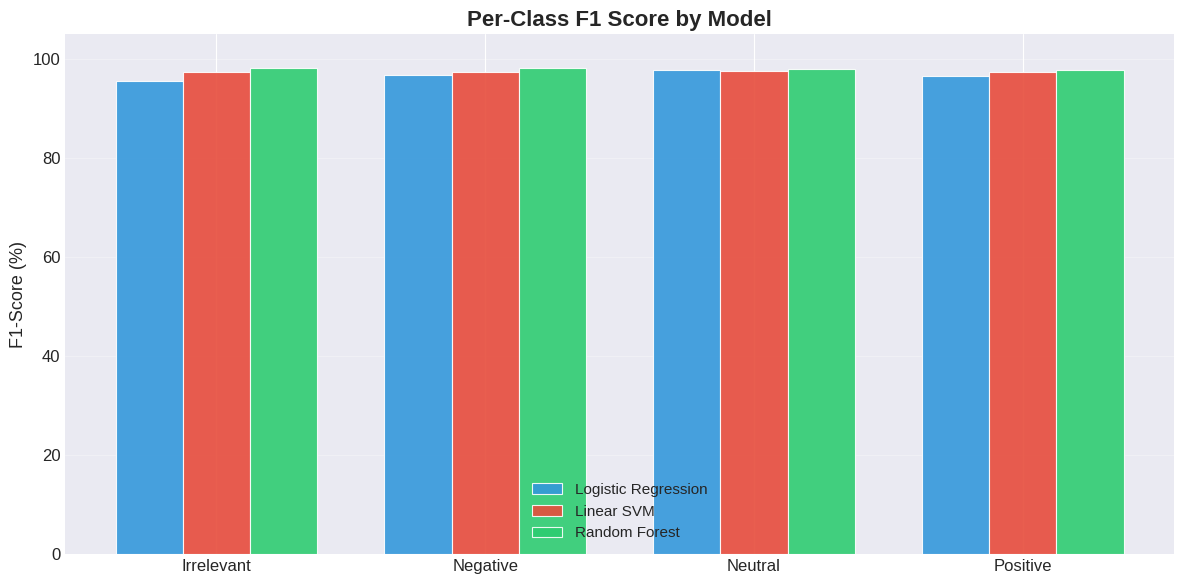

In [28]:
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(le.classes_))
width = 0.25
model_colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, (name, res) in enumerate(results.items()):
    per_class_f1 = f1_score(y_val_enc, res['predictions'], average=None)
    ax.bar(x + i * width, per_class_f1 * 100, width, label=name,
           color=model_colors[i], edgecolor='white',
           linewidth=0.8, alpha=0.9)

ax.set_ylabel('F1-Score (%)', fontsize=13)
ax.set_title('Per-Class F1 Score by Model', fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(le.classes_, fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

## 21. 🏆 Best Model Summary

In [29]:
best_name = max(results, key=lambda k: results[k]['accuracy'])
best_acc = results[best_name]['accuracy']
best_f1 = results[best_name]['f1_weighted']

print('=' * 60)
print('           🏆 BEST MODEL SUMMARY')
print('=' * 60)
print(f'  Model:              {best_name}')
print(f'  Validation Acc:     {best_acc:.4f} ({best_acc*100:.2f}%)')
print(f'  Weighted F1:        {best_f1:.4f} ({best_f1*100:.2f}%)')
print(f'  Training Time:      {train_times[best_name]:.1f}s')
print(f'  TF-IDF Features:    {X_train_tfidf.shape[1]:,}')
print(f'  Training Samples:   {X_train_tfidf.shape[0]:,}')
print(f'  Validation Samples: {len(X_val):,}')
print('=' * 60)

print('\n📊 All Models Ranking:')
for rank, (name, res) in enumerate(
    sorted(results.items(),
           key=lambda x: x[1]['accuracy'], reverse=True), 1
):
    print(f'  {rank}. {name:25s} → '
          f'Acc: {res["accuracy"]*100:.2f}%  |  '
          f'F1: {res["f1_weighted"]*100:.2f}%')

           🏆 BEST MODEL SUMMARY
  Model:              Random Forest
  Validation Acc:     0.9800 (98.00%)
  Weighted F1:        0.9800 (98.00%)
  Training Time:      521.3s
  TF-IDF Features:    50,000
  Training Samples:   69,008
  Validation Samples: 1,000

📊 All Models Ranking:
  1. Random Forest             → Acc: 98.00%  |  F1: 98.00%
  2. Linear SVM                → Acc: 97.40%  |  F1: 97.40%
  3. Logistic Regression       → Acc: 96.80%  |  F1: 96.79%


## 22. Sample Predictions

In [30]:
# Show sample predictions from the best model
best = trained_models[best_name]
sample_idx = np.random.RandomState(42).choice(
    len(X_val), size=10, replace=False
)

print(f'Sample Predictions — {best_name}\n')
print(f'{"Text":<70s} {"True":>12s} {"Predicted":>12s} {"Match":>6s}')
print('-' * 103)

for idx in sample_idx:
    text = X_val[idx][:65] + '...' if len(X_val[idx]) > 65 else X_val[idx]
    true_lbl = le.inverse_transform([y_val_enc[idx]])[0]
    pred_lbl = le.inverse_transform(
        [best.predict(X_val_tfidf[idx])[0]]
    )[0]
    match = '✓' if true_lbl == pred_lbl else '✗'
    print(f'{text:<70s} {true_lbl:>12s} {pred_lbl:>12s} {match:>6s}')

Sample Predictions — Random Forest

Text                                                                           True    Predicted  Match
-------------------------------------------------------------------------------------------------------
Remote working and an increase in cloud-based data is spurring cy...       Positive     Positive      ✓
I actually quite like the design of the ps5. It truly feels like ...       Positive     Positive      ✓
New York charges Johnson & Johnson with insurance fraud over opio...        Neutral      Neutral      ✓
Chris loves me in borderlands one and two.                                  Neutral      Neutral      ✓
Check out my video! #LeagueofLegends | Captured by #Outplayed #20...        Neutral      Neutral      ✓
Amazing deal for you! Lenovo Legion Y540 9th Gen Intel Core i5 15...        Neutral      Neutral      ✓
[PS4] | Assassins Creed Syndicate First Playthrough | Positive Vi...       Positive     Positive      ✓
servers down?               

In [1]:
from pathlib import Path
import joblib

BASE_DIR = Path(".").resolve()
MODELS_DIR = BASE_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Models will be saved to: {MODELS_DIR}")

Models will be saved to: C:\Sambit Programming\sentiment analyzer\models


In [4]:
# Choose the deployment model.
# If the notebook previously computed `best_name`, use it; otherwise default to Linear SVM.
deploy_name = globals().get("best_name", None) or "Linear SVM"

if "trained_models" not in globals():
    raise RuntimeError("`trained_models` not found. Run the training cells before exporting.")

if deploy_name not in trained_models:
    raise KeyError(
        f"Deploy model '{deploy_name}' not found in trained_models. "
        f"Available: {list(trained_models.keys())}"
    )

DEPLOY_MODEL_NAME = deploy_name
deploy_model = trained_models[DEPLOY_MODEL_NAME]
print(f"Deployment model set to: {DEPLOY_MODEL_NAME}")

RuntimeError: `trained_models` not found. Run the training cells before exporting.

In [5]:
from pathlib import Path
import json
import joblib

# Ensure MODELS_DIR exists (so this cell is safe to run even if cells 54/55 were skipped)
MODELS_DIR = globals().get("MODELS_DIR", Path(".").resolve() / "models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Prefer the best model selected in the notebook; otherwise fall back.
deploy_name = globals().get("best_name", None) or "Linear SVM"

if "trained_models" not in globals():
    raise RuntimeError("`trained_models` not found. Run training cells before exporting.")

if deploy_name not in trained_models:
    raise KeyError(
        f"Deploy model '{deploy_name}' not found in trained_models. "
        f"Available: {list(trained_models.keys())}"
    )

# Ensure required training artifacts exist
for needed in ["tfidf", "le"]:
    if needed not in globals():
        raise RuntimeError(f"Missing required object `{needed}`. Run preprocessing/training cells first.")

DEPLOY_MODEL_NAME = deploy_name
deploy_model = trained_models[DEPLOY_MODEL_NAME]

# Save artifacts expected by the FastAPI backend
(tfidf_path := MODELS_DIR / "tfidf_vectorizer.joblib")
joblib.dump(tfidf, tfidf_path)

(model_path := MODELS_DIR / "sentiment_model.joblib")
joblib.dump(deploy_model, model_path)

(le_path := MODELS_DIR / "label_encoder.joblib")
joblib.dump(le, le_path)

metadata_path = MODELS_DIR / "metadata.json"
metadata = {
    "model_name": DEPLOY_MODEL_NAME,
    "label_classes": list(le.classes_),
    "vectorizer_max_features": getattr(tfidf, "max_features", None),
    "ngram_range": getattr(tfidf, "ngram_range", None),
}

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Export complete.")
print(f"  TF-IDF vectorizer: {tfidf_path}")
print(f"  Sentiment model:  {model_path}")
print(f"  Label encoder:    {le_path}")
print(f"  Metadata:         {metadata_path}")
print(f"  Deploy model name: {DEPLOY_MODEL_NAME}")

RuntimeError: `trained_models` not found. Run training cells before exporting.

In [ ]:
# === Export model artifacts for the production web app ===
from pathlib import Path
import json
import joblib

MODELS_DIR = Path(".").resolve() / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Prefer the best model selected in the notebook; fallback to a sane default.
deploy_name = globals().get("best_name", None) or "Linear SVM"

if "trained_models" not in globals():
    raise RuntimeError("`trained_models` not found. Run the training cells before exporting.")

if deploy_name not in trained_models:
    raise KeyError(
        f"Deploy model '{deploy_name}' not found in trained_models. "
        f"Available: {list(trained_models.keys())}"
    )

deploy_model = trained_models[deploy_name]

# Ensure required training artifacts exist
required = ["tfidf", "le"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects for export: {missing}. Run preprocessing/training cells.")

# Save artifacts expected by the FastAPI backend
(tfidf_path := MODELS_DIR / "tfidf_vectorizer.joblib")
joblib.dump(tfidf, tfidf_path)

(model_path := MODELS_DIR / "sentiment_model.joblib")
joblib.dump(deploy_model, model_path)

(le_path := MODELS_DIR / "label_encoder.joblib")
joblib.dump(le, le_path)

# Optional metadata
metadata_path = MODELS_DIR / "metadata.json"
metadata = {
    "model_name": deploy_name,
    "label_classes": list(le.classes_),
    "vectorizer_max_features": getattr(tfidf, "max_features", None),
    "ngram_range": getattr(tfidf, "ngram_range", None),
}
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Export complete.")
print(f"  TF-IDF vectorizer: {tfidf_path}")
print(f"  Sentiment model:  {model_path}")
print(f"  Label encoder:    {le_path}")
print(f"  Metadata:         {metadata_path}")
print(f"  Deploy model name: {deploy_name}")
